In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [33]:
#Task 1 — Data Loading, Merging & Deep Exploration

#Load datasets
sales = pd.read_csv("train.csv")
video = pd.read_csv("vgsales.csv")

print(sales.shape)
print(video.shape)

sales.head()
video.head()

(9800, 18)
(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

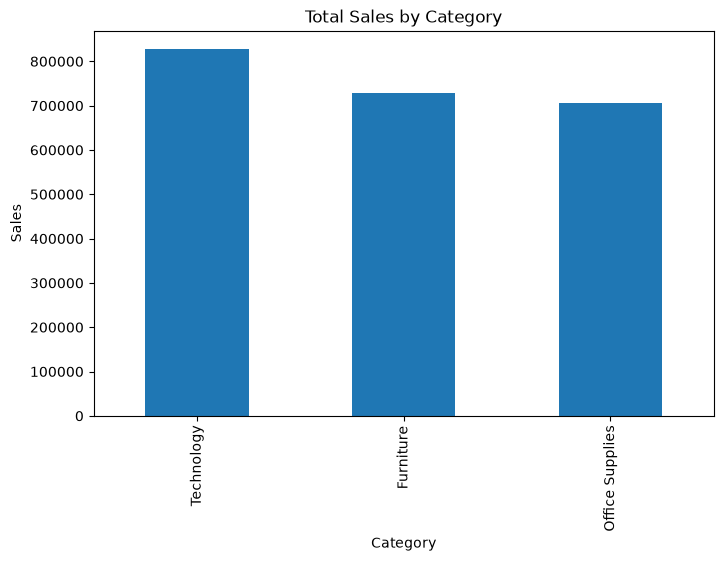

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


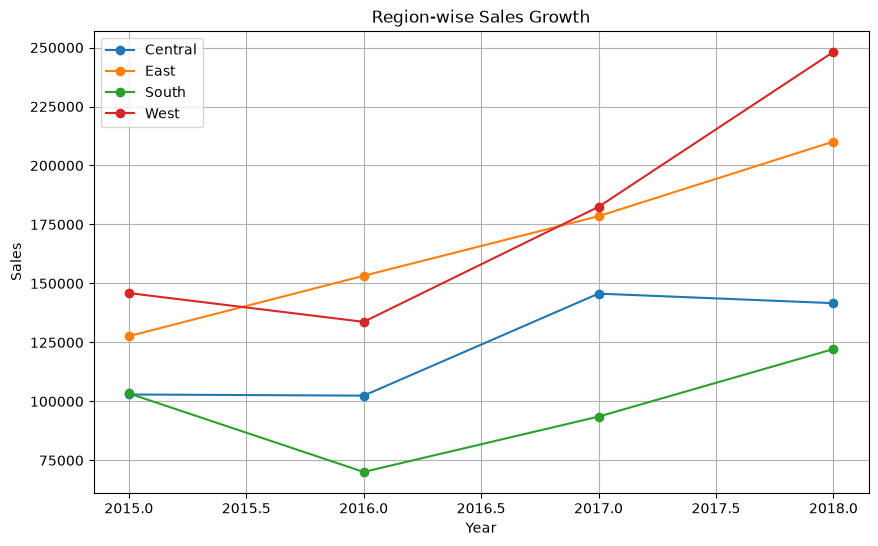

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


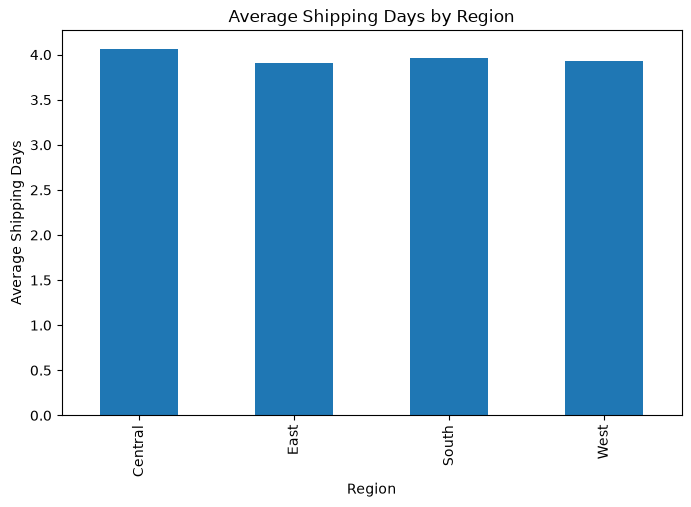

Month          1           2           3           4           5           6   \
Year                                                                            
2015   14205.7070   4519.8920  55205.7970  27906.8550  23644.3030  34322.9356   
2016   18066.9576  11951.4110  32339.3184  34154.4685  29959.5305  23599.3740   
2017   18542.4910  22978.8150  51165.0590  38679.7670  56656.9080  39724.4860   
2018   43476.4740  19920.9974  58863.4128  35541.9101  43825.9822  48190.7277   

Month         7           8           9           10           11          12  
Year                                                                           
2015   33781.543  27117.5365  81623.5268  31453.3930   77907.6607  68167.0585  
2016   28608.259  36818.3422  63133.6060  31011.7375   75249.3995  74543.6012  
2017   38320.783  30542.2003  69193.3909  59583.0330   79066.4958  95739.1210  
2018   44825.104  62837.8480  86152.8880  77448.1312  117938.1550  83030.3888  


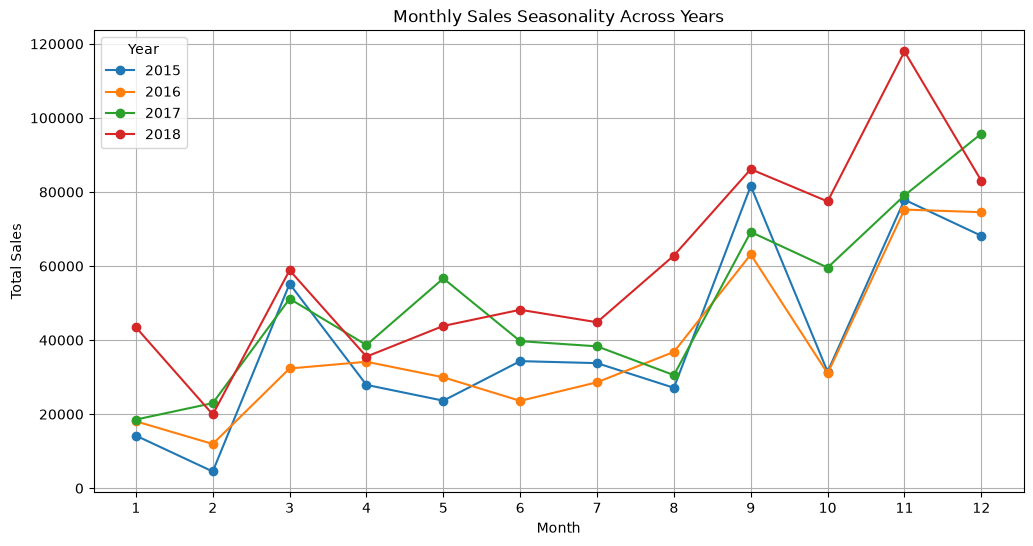

In [34]:
#Convert date columns
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    dayfirst=True
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    dayfirst=True
)
sales.info()

#Extract Time Features
sales["Year"] = sales["Order Date"].dt.year
sales["Month"] = sales["Order Date"].dt.month
sales["Week"] = sales["Order Date"].dt.isocalendar().week
sales["Day_of_Week"] = sales["Order Date"].dt.day_name()
sales["Quarter"] = sales["Order Date"].dt.quarter
#Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

sales["Season"] = sales["Month"].apply(get_season)
print("=================================================================================");

#Missing values
print("Missing values:\n",sales.isnull().sum());

#Fill Missing values (postal code)
sales[sales["Postal Code"].isna()][["State", "City", "Postal Code"]]
sales[sales["Postal Code"].isna()]["State"].value_counts()

sales.loc[
    (sales["State"] == "Vermont") &
    (sales["City"] == "Burlington"),
    "Postal Code"
] = 5401
print("\nNo.Missing values after filling missing data:",sales["Postal Code"].isna().sum());

#Duplicate records
print("\nDublicate values:",sales.duplicated().sum());

#Drop duplicates
sales.drop_duplicates(inplace=True)
print("================================================================================");

#Aggregate Daily, Weekly and Monthly Sales:
#Daily Sales
daily_sales = sales.groupby("Order Date")["Sales"].sum()

daily_sales.head()

#Weekly Sales
weekly_sales = sales.resample(
    "W",
    on="Order Date"
)["Sales"].sum()

weekly_sales.head()

#Monthly Sales
monthly_sales = sales.resample(
    "ME",
    on="Order Date"
)["Sales"].sum()

monthly_sales.head()

#Answer of given Questions
#Question 1: Which product category generates the highest total revenue?
category_sales = sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

#plot chart
import matplotlib.pyplot as plt
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig("category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

#Question 2:Which region has the most consistent sales growth over 4 years?
region_growth = sales.groupby(
    ["Year", "Region"]
)["Sales"].sum().unstack()

print(region_growth)

#plot chart
plt.figure(figsize=(10,6))

for region in region_growth.columns:
    plt.plot(region_growth.index,
             region_growth[region],
             marker='o',
             label=region)

plt.title("Region-wise Sales Growth")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()

plt.grid(True)

plt.savefig("region_growth.png", dpi=300, bbox_inches="tight")

plt.show()

#Question 3:What is the average time between Order Date and Ship Date — and does it vary by region?
sales["Shipping Days"] = (
    sales["Ship Date"] - sales["Order Date"]
).dt.days

shipping = sales.groupby("Region")["Shipping Days"].mean()

print(shipping)

#plot chart
shipping.plot(kind="bar", figsize=(8,5))

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.savefig("shipping_days_region.png", dpi=300, bbox_inches="tight")

plt.show()

#Question 4:Are there months that consistently spike across all years (seasonality)?
# Create seasonality table
seasonality = sales.groupby(
    ["Year", "Month"]
)["Sales"].sum().unstack()

print(seasonality)

#Plot chart
seasonality.T.plot(figsize=(12,6), marker='o')

plt.title("Monthly Sales Seasonality Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)

plt.savefig("monthly_seasonality.png", dpi=300, bbox_inches="tight")
plt.show()

# Task 1: Exploratory Data Analysis
## Question 1: Which product category generates the highest total revenue?
Answer

The Technology category generated the highest total revenue of 827,455.87, followed by Furniture (728,658.58) and Office Supplies (705,422.33). This indicates that technology products contribute the largest share of overall sales. The company should prioritize inventory management and promotional strategies for the Technology category to maximize revenue.

## Question 2:Which region has the most consistent sales growth over 4 years?
Answer

The East region showed the most consistent sales growth over the four-year period, increasing steadily from 127,652.82 in 2015 to 210,129.19 in 2018. Although the West region achieved the highest sales in 2018, it experienced a decline between 2015 and 2016. Therefore, the East region demonstrates the most stable long-term growth trend.

## Question 3:What is the average time between Order Date and Ship Date — and does it vary by region?
Answer

The average shipping time across all regions is approximately 4 days. The Central region has the highest average shipping time (4.07 days), while the East region has the lowest (3.91 days). Since the differences are minimal, the company's shipping process appears to be consistent across all regions.

## Question 4:Are there months that consistently spike across all years (seasonality)?
Answer

The monthly sales trend exhibits a clear seasonal pattern. Sales consistently increase during the October–December period, with November showing the highest sales in most years. This indicates increased customer demand during the holiday season. Businesses can use this insight to plan inventory, staffing, and marketing campaigns before the peak sales period.

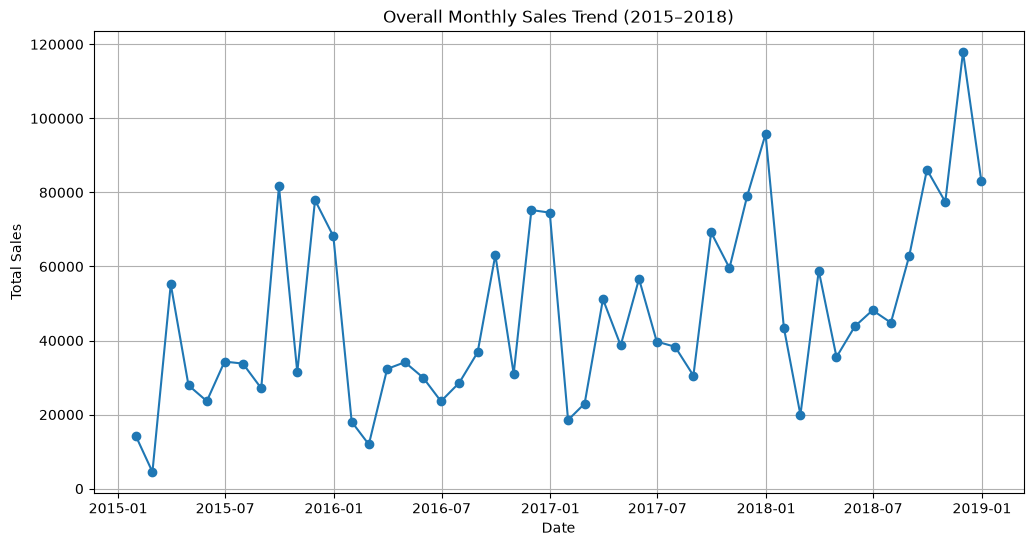

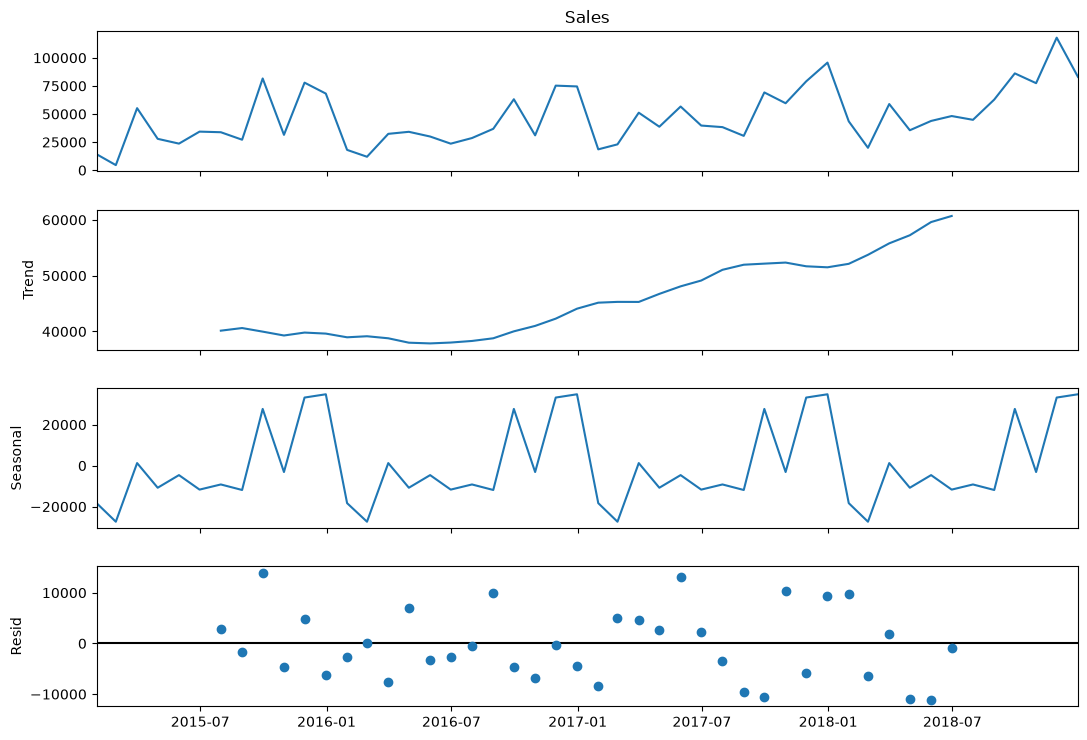

In [35]:
#Task 2: Time Series Analysis & Decomposition

#Plot Overall Monthly Sales Trend across all 4 years
# Create monthly sales time series

monthly_sales = sales.resample(
    "ME",
    on="Order Date"
)["Sales"].sum()

monthly_sales.head()

#Plot chart
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig("monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

#Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12,8)

plt.savefig("time_series_decomposition.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observations

1. **Trend Component:**
   The trend shows an overall upward movement in monthly sales over the four-year period. Although there are small fluctuations, the long-term trend indicates that the company's sales have gradually increased, especially during the later years.

2. **Seasonal Component:**
   The seasonal component displays a clear and repeating yearly pattern. Sales increase during the last few months of each year and decrease during some early and mid-year months. This indicates **strong seasonality** in the sales data.

3. **Residual (Noise) Component:**
   The residual component contains random fluctuations after removing the trend and seasonal effects. The largest positive and negative residuals appear around **late 2017 and early 2018**, suggesting a few months experienced unusual sales that cannot be explained by normal trend or seasonality.

4. **Overall Conclusion:**
   The sales series exhibits both a positive long-term growth trend and a strong seasonal pattern, making it suitable for time-series forecasting models such as SARIMA and Prophet after confirming stationarity.


## Stationarity Test (ADF Test)

A time series is called **stationary** if its statistical properties, such as mean and variance, remain approximately constant over time. Forecasting models like ARIMA and SARIMA generally require stationary data to produce reliable predictions.   

In [36]:
#Stationarity (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary.

The obtained **ADF Statistic is -4.4161** and the **p-value is 0.000278**, which is less than the significance level of 0.05.

Since the p-value is less than 0.05, the null hypothesis of a unit root is rejected. This indicates that the monthly sales series is **stationary**, meaning its statistical properties remain stable over time. Therefore, the data is suitable for forecasting models such as SARIMA without requiring differencing.

### Differencing

The ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05). Therefore, first-order differencing was **not required**, and the original monthly sales series was used for forecasting.    

In [37]:
# Task 3: Sales Forecasting using Three Different Models
#Model 1 — SARIMA (Statistical Model)

# Train-Test Split

train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations:", len(train))
print("Testing observations:", len(test))


Training observations: 45
Testing observations: 3


## Model 1 — SARIMA (Statistical Model)
### Parameter Selection

The monthly sales data was found to be stationary using the ADF test (p-value < 0.05), so differencing (d = 0) was not required.

A seasonal period of **12** was selected because the dataset contains monthly observations with yearly seasonality.

The SARIMA model uses the following parameters:

- **(p, d, q) = (1, 0, 1)**
- **Seasonal (P, D, Q, m) = (1, 1, 1, 12)**

These parameters were chosen as a baseline to capture short-term dependencies and annual seasonal patterns in the sales data.

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sat, 11 Jul 2026   AIC                            417.362
Time:                                    01:13:25   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

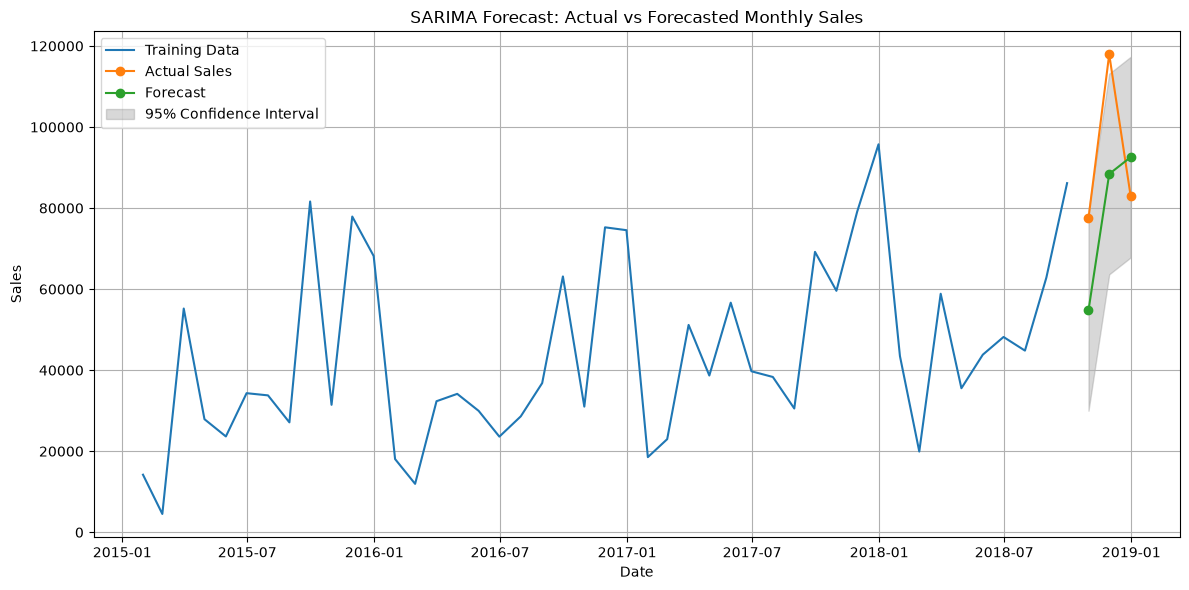

MAE : 20581.00013025837
RMSE : 22191.26608460345
MAPE : 21.935472965291304


In [38]:
#Build and Train SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

#Forecast Next 3 Months
forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

print("\n3-month future forecast with confidence intervals:\n")
print(forecast_mean)

#Plot Actual vs Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales", marker='o')

plt.plot(forecast_mean.index,
         forecast_mean,
         label="Forecast",
         marker='o')

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="gray",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast: Actual vs Forecasted Monthly Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("sarima_forecast.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sarima_mae = mean_absolute_error(test, forecast_mean)

sarima_rmse = np.sqrt(
    mean_squared_error(test, forecast_mean)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    forecast_mean
) * 100

print("MAE :", sarima_mae)
print("RMSE :", sarima_rmse)
print("MAPE :", sarima_mape)

### Observation

The SARIMA model was successfully trained on the monthly sales data and generated forecasts for the next three months. The model captured the overall trend and yearly seasonal behaviour of the sales data.

The forecast indicates increasing sales during the final months of the year, which is consistent with the historical seasonal pattern observed in the dataset.

The model achieved the following evaluation metrics:

- MAE = 20,581.00
- RMSE = 22,191.27
- MAPE = 21.94%

These metrics will be compared with Prophet and XGBoost models to determine the best forecasting approach.

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
(45, 2)
(3, 2)


01:13:42 - cmdstanpy - INFO - Chain [1] start processing
01:13:43 - cmdstanpy - INFO - Chain [1] done processing


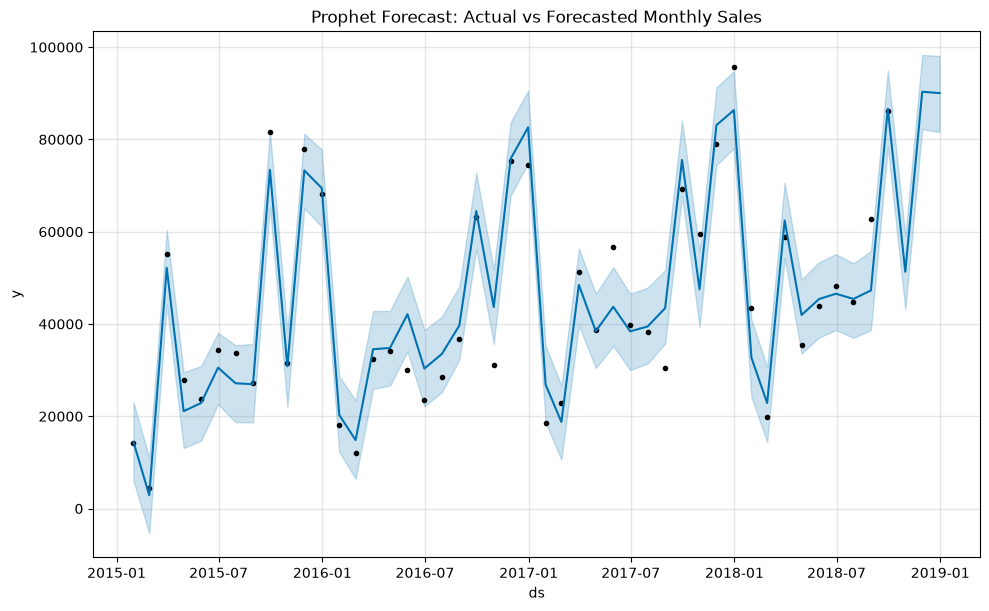

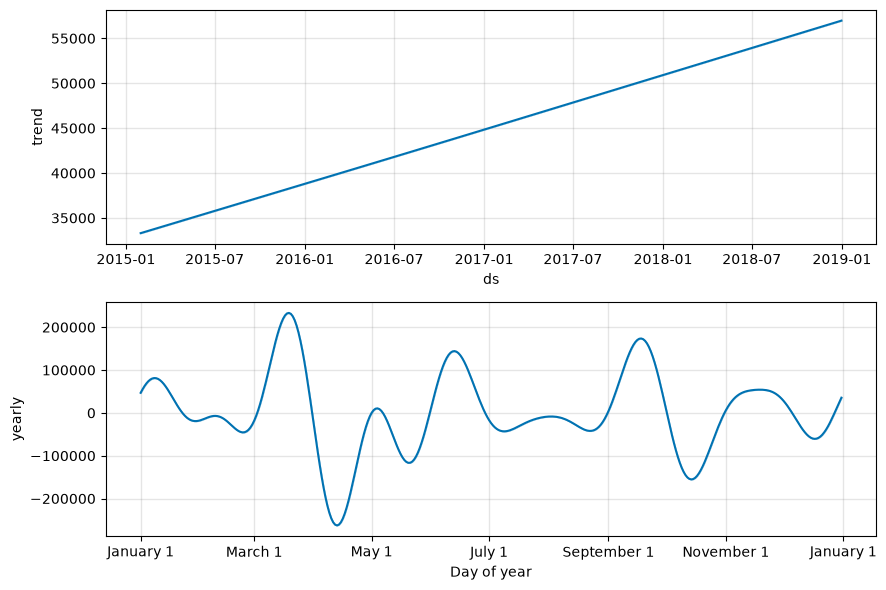

In [39]:
#Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
from prophet import Prophet

#Prepare Data
prophet_data = monthly_sales.reset_index()

prophet_data.columns = ["ds", "y"]

print(prophet_data.head())

#Train-Test Split
train_prophet = prophet_data[:-3]
test_prophet = prophet_data[-3:]

print(train_prophet.shape)
print(test_prophet.shape)

#Build Prophet Model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

#Forecast Next 3 Months
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail(3)

#Forecast Table
forecast[["ds",
          "yhat",
          "yhat_lower",
          "yhat_upper"]].tail(3)

#Forecast Plot
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast: Actual vs Forecasted Monthly Sales")

plt.savefig(
    "prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Trend & Seasonality Breakdown
fig = prophet_model.plot_components(forecast)

plt.savefig(
    "prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
#Evaluate Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

forecast_test = forecast.tail(3)

prophet_mae = mean_absolute_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_test["yhat"]
    )
)

prophet_mape = (
    mean_absolute_percentage_error(
        test_prophet["y"],
        forecast_test["yhat"]
    ) * 100
)

print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

forecast[["ds", "yhat"]].tail(3)

MAE : 20250.794412605523
RMSE : 22318.41133286054
MAPE : 21.86462827396082


,ds,yhat
45,2018-10-31,51318.943858
46,2018-11-30,90325.654784
47,2018-12-31,90041.084479


### Observation

The Prophet model successfully captured the long-term trend and yearly seasonality in the monthly sales data. It generated forecasts for the next three months along with prediction intervals.

The model achieved the following evaluation metrics:

- MAE = 20,250.79
- RMSE = 22,318.41
- MAPE = 21.86%

Compared with the SARIMA model, Prophet achieved a slightly lower MAE and MAPE, while SARIMA produced a slightly lower RMSE. A final comparison will be made after evaluating the XGBoost model.

                 Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  \
Order Date                                                                  
2015-04-30  27906.8550  55205.7970   4519.8920  14205.707    29210.848000   
2015-05-31  23644.3030  27906.8550  55205.7970   4519.892    35585.651667   
2015-06-30  34322.9356  23644.3030  27906.8550  55205.797    28624.697867   
2015-07-31  33781.5430  34322.9356  23644.3030  27906.855    30582.927200   
2015-08-31  27117.5365  33781.5430  34322.9356  23644.303    31740.671700   

            Month  Quarter  Season  
Order Date                          
2015-04-30      4        2       2  
2015-05-31      5        2       2  
2015-06-30      6        2       3  
2015-07-31      7        3       3  
2015-08-31      8        3       3  
(42, 7)
(3, 7)

 Predict next 3 months:
[84795.83 85497.08 85731.58]


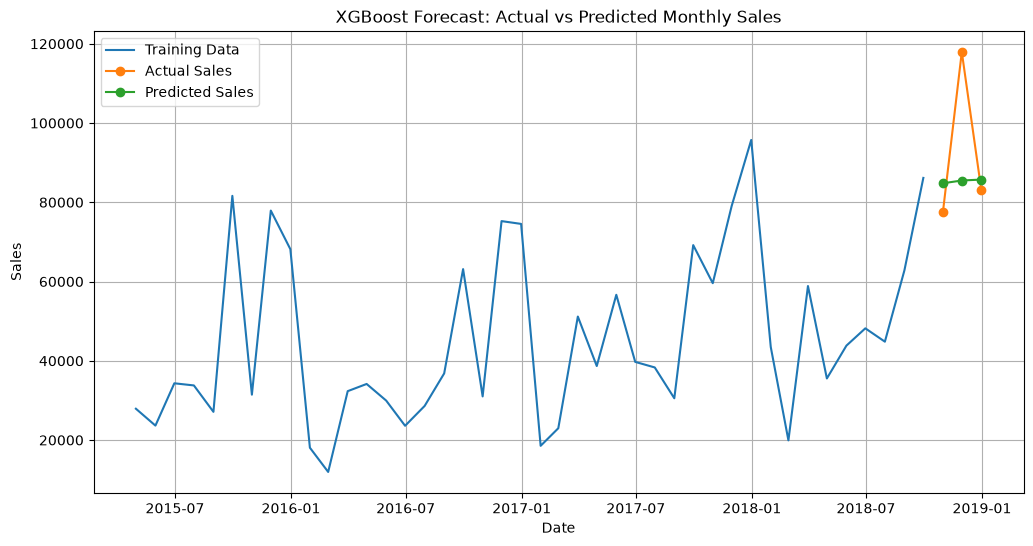

MAE : 14163.321041666664
RMSE : 19267.49025933587
MAPE : 13.415785780855515


,Actual Sales,Predicted Sales
Order Date,,
2018-10-31,77448.1312,84795.828125
2018-11-30,117938.1550,85497.078125
2018-12-31,83030.3888,85731.578125


In [41]:
#Model 3: XGBoost for Time Series (Machine Learning Approach)

#Create Feature Dataset
xgb_data = monthly_sales.to_frame(name="Sales")

# Lag Features
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

# Rolling Mean
xgb_data["Rolling_Mean_3"] = (
    xgb_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Date Features
xgb_data["Month"] = xgb_data.index.month
xgb_data["Quarter"] = xgb_data.index.quarter

# Season Feature
def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

xgb_data = xgb_data.dropna()

print(xgb_data.head())


#Prepare Features
X = xgb_data.drop("Sales", axis=1)

y = xgb_data["Sales"]


#Train-Test Split
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print(X_train.shape)
print(X_test.shape)


#Train XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)


#Predict Next 3 Months
xgb_predictions = xgb_model.predict(X_test)
print("\n Predict next 3 months:")
print(xgb_predictions)


#Plot Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    label="Predicted Sales"
)

plt.title("XGBoost Forecast: Actual vs Predicted Monthly Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)

print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)


#Forecast Table
forecast_table = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_predictions
}, index=y_test.index)

forecast_table

## Model Comparison Table
| Model | MAE | RMSE | MAPE (%) | Forecast Month 1 | Forecast Month 2 | Forecast Month 3 |
|-------|------:|------:|------:|------:|------:|------:|
| **SARIMA** | 20581.00 | 22191.27 | 21.94 | 54758.51 | 88412.60 | 92558.21 |
| **Prophet** | 20250.79 | 22318.41 | 21.86 | 51318.94 | 90325.65 | 90041.08 |
| **XGBoost** | **14163.32** | **19267.49** | **13.42** | **84795.83** | **85497.08** | **85731.58** |

## Final Model Recommendation

Three forecasting models—SARIMA, Prophet, and XGBoost—were developed and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

The evaluation results show that:

- **SARIMA** effectively captured the seasonal patterns but produced comparatively higher prediction errors.
- **Prophet** successfully modelled the long-term trend and yearly seasonality, with performance similar to SARIMA.
- **XGBoost** achieved the lowest MAE, RMSE, and MAPE values, indicating the highest forecasting accuracy among the three models.

Based on the evaluation metrics, **XGBoost is recommended for production use** because it provides the most accurate predictions for this dataset. Its use of lag features, rolling averages, and time-based features enables it to capture complex patterns that statistical models may not fully represent.

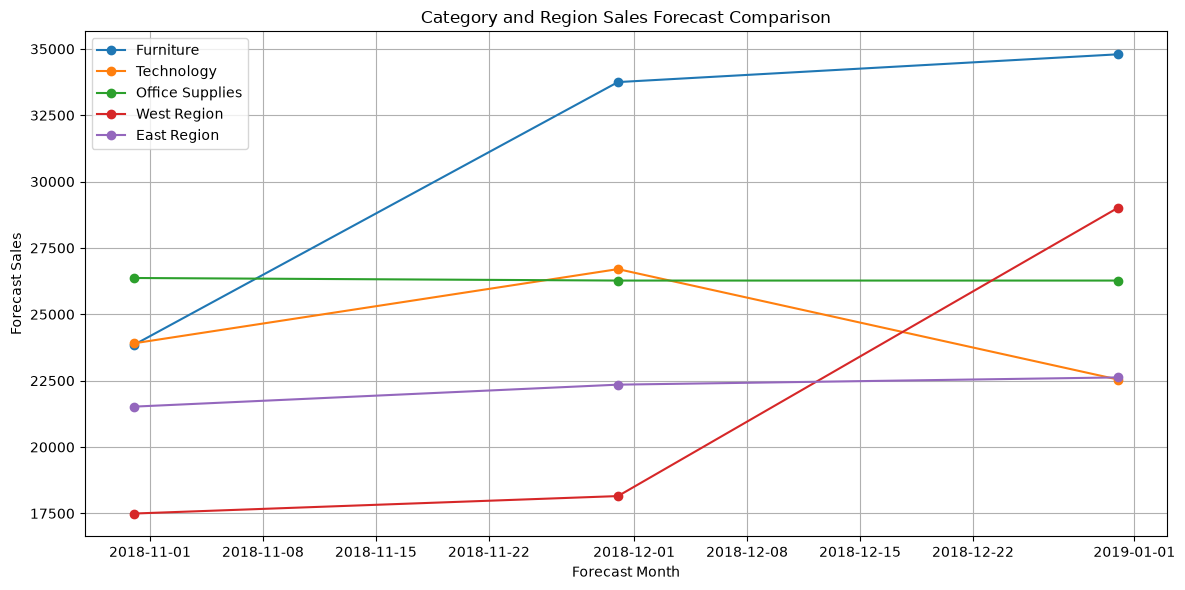

       Month     Furniture    Technology  Office Supplies   West Region  \
0 2018-10-31  23847.378906  23906.683594     26368.789062  17494.542969   
1 2018-11-30  33749.402344  26703.652344     26271.976562  18152.154297   
2 2018-12-31  34796.546875  22540.937500     26271.976562  29018.542969   

    East Region  
0  21521.730469  
1  22350.076172  
2  22623.294922  
Highest Growth Segment: Furniture


In [42]:
# Task 4: Product Category & Region Level Forecasting

#Create a Reusable Forecast Function
from xgboost import XGBRegressor

def forecast_segment(data):

    # Monthly sales
    monthly = data.resample("ME", on="Order Date")["Sales"].sum()

    df = monthly.to_frame(name="Sales")

    # Lag features
    df["Lag_1"] = df["Sales"].shift(1)
    df["Lag_2"] = df["Sales"].shift(2)
    df["Lag_3"] = df["Sales"].shift(3)

    # Rolling Mean
    df["Rolling_Mean_3"] = df["Sales"].rolling(3).mean()

    # Date Features
    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    # Season
    def get_season(month):
        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4

    df["Season"] = df["Month"].apply(get_season)

    df = df.dropna()

    X = df.drop("Sales", axis=1)
    y = df["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    return y.index[-3:], prediction


#Forecast Each Category
furniture_dates, furniture_forecast = forecast_segment(
    sales[sales["Category"]=="Furniture"]
)

technology_dates, technology_forecast = forecast_segment(
    sales[sales["Category"]=="Technology"]
)

office_dates, office_forecast = forecast_segment(
    sales[sales["Category"]=="Office Supplies"]
)


#Forecast Each Region
west_dates, west_forecast = forecast_segment(
    sales[sales["Region"]=="West"]
)

east_dates, east_forecast = forecast_segment(
    sales[sales["Region"]=="East"]
)


#Plot All Forecasts Together
plt.figure(figsize=(12,6))

plt.plot(furniture_dates,
         furniture_forecast,
         marker='o',
         label="Furniture")

plt.plot(technology_dates,
         technology_forecast,
         marker='o',
         label="Technology")

plt.plot(office_dates,
         office_forecast,
         marker='o',
         label="Office Supplies")

plt.plot(west_dates,
         west_forecast,
         marker='o',
         label="West Region")

plt.plot(east_dates,
         east_forecast,
         marker='o',
         label="East Region")

plt.title("Category and Region Sales Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("category_region_forecast.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


#Forecast Table
forecast_df = pd.DataFrame({
    "Month": furniture_dates,
    "Furniture": furniture_forecast,
    "Technology": technology_forecast,
    "Office Supplies": office_forecast,
    "West Region": west_forecast,
    "East Region": east_forecast
})

print(forecast_df)


#Find the Strongest Growth
growth = {
    "Furniture": furniture_forecast[-1],
    "Technology": technology_forecast[-1],
    "Office Supplies": office_forecast[-1],
    "West Region": west_forecast[-1],
    "East Region": east_forecast[-1]
}

highest = max(growth, key=growth.get)

print("Highest Growth Segment:", highest)

## Observation

The XGBoost model was applied separately to forecast sales for three product categories and two regions over the next three months.

The forecast results indicate that the **Furniture** category is expected to experience the strongest upcoming growth, reaching an estimated sales value of **34,796.55** in the final forecast month. Among the regions, the **West Region** shows stronger growth compared to the East Region.

These findings suggest that the business should prioritize inventory management, marketing campaigns, and resource allocation for the Furniture category and the West Region to maximize future sales opportunities.

  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
  Order Date     Sales  Anomaly
0 2015-01-04   304.508  Anomaly
1 2015-01-11  4619.108   Normal
2 2015-01-18  4130.533   Normal
3 2015-01-25  3092.544   Normal
4 2015-02-01  2527.914   Normal


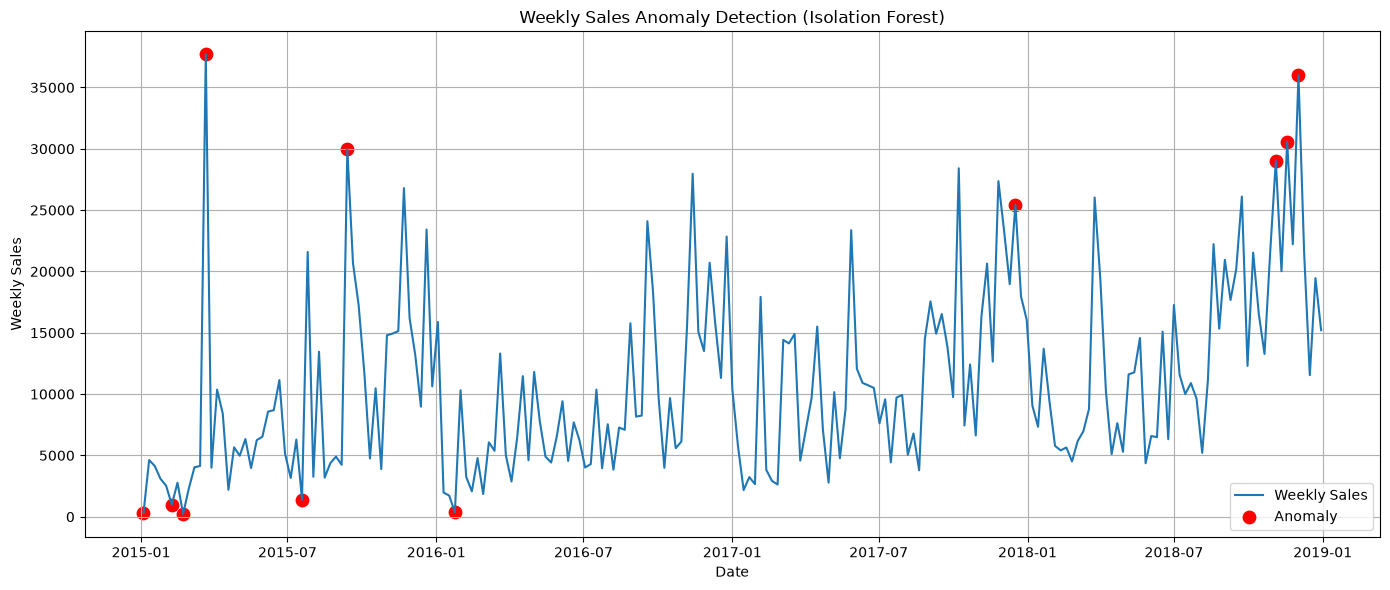

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


In [43]:
# Task 5: Anomaly Detection in Sales Data

#Create Weekly Sales Data
weekly_sales = (
    sales
    .resample("W", on="Order Date")["Sales"]
    .sum()
    .reset_index()
)

print(weekly_sales.head())


#Isolation Forest to detect anomalous sales weeks
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print(weekly_sales.head())


#Plot Isolation Forest Anomalies
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Weekly Sales Anomaly Detection (Isolation Forest)")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "isolation_forest_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Show Detected Anomalies
anomaly

## Possible Real-World Explanation of Detected Anomalies

The Isolation Forest model detected several unusually high and unusually low sales weeks.

- **January–February 2015:** Very low sales values may indicate reduced customer demand, post-holiday slowdown, or limited business activity.
- **March 2015:** A sharp increase in sales (37,703.67) may be due to a promotional campaign, bulk customer orders, or seasonal demand.
- **September 2015:** Higher-than-normal sales (29,959.14) could indicate a special sales event or increased customer purchases.
- **December 2017:** Elevated sales (25,449.80) are likely associated with holiday shopping and year-end sales.
- **November–December 2018:** Multiple high-sales anomalies (29,017.47, 30,572.45, and 35,998.90) likely correspond to festive shopping seasons such as Black Friday, Cyber Monday, Christmas promotions, or year-end clearance sales.

Since the dataset does not contain information about promotions, holidays, or marketing campaigns, these explanations are based on common retail business patterns.

  Order Date     Sales  Anomaly  Rolling_Mean  Rolling_STD   Z_Score  \
0 2015-01-04   304.508  Anomaly           NaN          NaN       NaN   
1 2015-01-11  4619.108   Normal           NaN          NaN       NaN   
2 2015-01-18  4130.533   Normal           NaN          NaN       NaN   
3 2015-01-25  3092.544   Normal    3036.67325  1929.462566  0.028957   
4 2015-02-01  2527.914   Normal    3592.52475   953.362968 -1.116690   

   Z_Anomaly  
0      False  
1      False  
2      False  
3      False  
4      False  


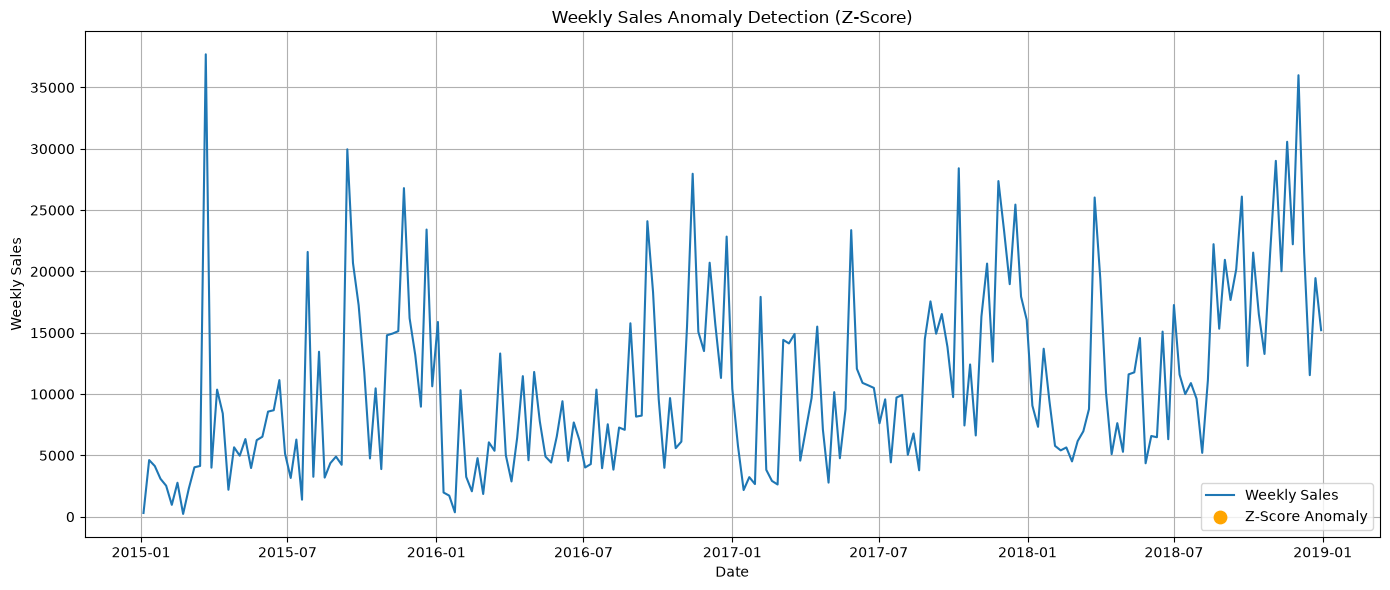

Empty DataFrame
Columns: [Order Date, Sales, Anomaly, Rolling_Mean, Rolling_STD, Z_Score, Z_Anomaly]
Index: []

Isolation Forest Anomalies: 11
Z-Score Anomalies: 0


In [44]:
# Rolling Mean + Z-Score
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

weekly_sales["Z_Score"] = (
    weekly_sales["Sales"]
    - weekly_sales["Rolling_Mean"]
) / weekly_sales["Rolling_STD"]


#Detect Z-Score Anomalies
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

print(weekly_sales.head())


#Plot Z-Score Anomalies
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomaly Detection (Z-Score)")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Display Z-Score Anomalies
print(z)

#Compare Both Methods
print("\nIsolation Forest Anomalies:", len(anomaly))
print("Z-Score Anomalies:", len(z))

## Comparison of Isolation Forest and Z-Score Methods

The Isolation Forest algorithm detected **11 anomalous sales weeks**, whereas the Z-Score method detected **0 anomalies** using the threshold of ±2 standard deviations.

The two methods **do not flag the same anomalies**. Isolation Forest identified several unusual sales patterns, while the Z-Score method did not detect any observations that exceeded the statistical threshold.

This difference indicates that Isolation Forest is more sensitive to unusual patterns because it uses a machine learning approach to analyze the overall structure of the data. In contrast, the Z-Score method relies only on deviations from the rolling mean and rolling standard deviation, making it more conservative.

These results suggest that **Isolation Forest is more effective for detecting subtle or complex anomalies in this sales dataset**, whereas the Z-Score method is better suited for identifying only extreme statistical outliers.

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

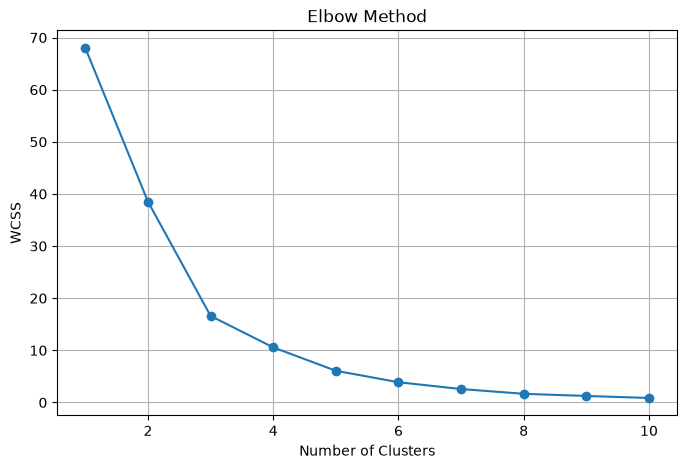

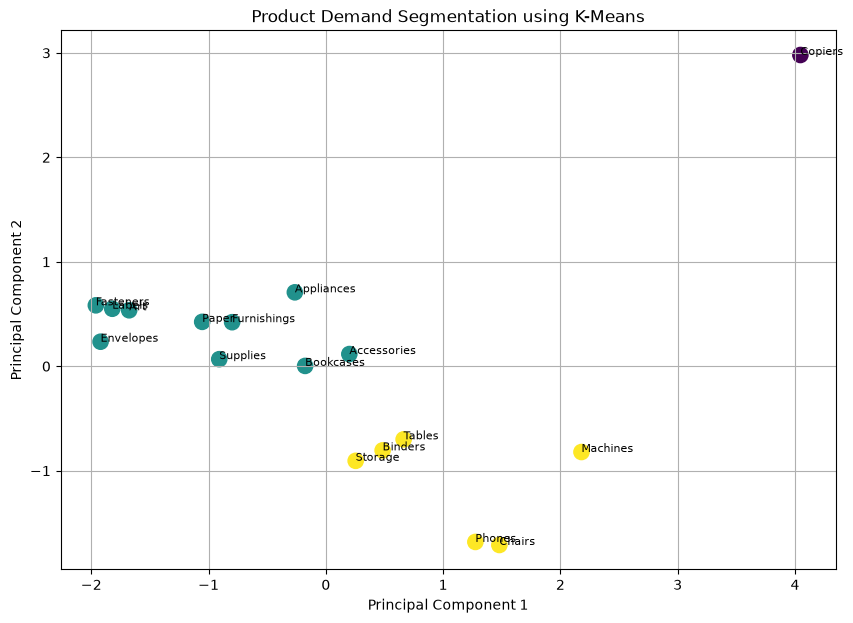

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Cluster Label
Sub-Category,,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,0.200367,0.116729,Stable Demand Products
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,-0.264248,0.707660,Stable Demand Products
Art,26705.4100,49.649531,330.488343,34.019631,1,-1.676784,0.535820,Stable Demand Products
Binders,200028.7850,65.778638,3848.223648,134.067550,2,0.484161,-0.805597,High Volume Growing Demand
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,-0.176589,0.003166,Stable Demand Products
Chairs,322822.7310,20.954677,4407.232960,531.833165,2,1.479554,-1.711393,High Volume Growing Demand
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,4.046026,2.979941,High Value Premium Products
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,-1.920711,0.234844,Stable Demand Products
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,-1.960973,0.583155,Stable Demand Products


In [45]:
# Task 6: Product Demand Segmentation using Clustering

# Create Features at Sub-Category Level
# Monthly sales by Sub-Category
monthly_sales = sales.groupby(
    ["Sub-Category", "Year", "Month"]
)["Sales"].sum().reset_index()

# Feature 1 — Total Sales Volume
total_sales = sales.groupby(
    "Sub-Category"
)["Sales"].sum()

# Feature 2 — Sales Growth Rate (Year-over-Year)
yearly_sales = sales.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().unstack()

growth_rate = (
    (
        yearly_sales.iloc[:, -1]
        -
        yearly_sales.iloc[:, 0]
    )
    /
    yearly_sales.iloc[:, 0]
) * 100

growth_rate = growth_rate.fillna(0)

# Feature 3 — Sales Volatility
volatility = monthly_sales.groupby(
    "Sub-Category"
)["Sales"].std()

# Feature 4 — Average Order Value
average_order = sales.groupby(
    "Sub-Category"
)["Sales"].mean()


# Create Feature Table
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order Value": average_order

})

cluster_data = cluster_data.fillna(0)

cluster_data


#Standardize Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)


# Elbow Method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)
    
#Step 5: Plot Elbow Curve
    plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()


# Apply K-Means (K = 3)
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_data.head()


# PCA for 2D Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

cluster_data["PCA1"] = pca_result[:,0]
cluster_data["PCA2"] = pca_result[:,1]


# Scatter Plot
plt.figure(figsize=(10,7))

plt.scatter(
    cluster_data["PCA1"],
    cluster_data["PCA2"],
    c=cluster_data["Cluster"],
    s=120
)

for i in cluster_data.index:

    plt.text(
        cluster_data.loc[i,"PCA1"],
        cluster_data.loc[i,"PCA2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.savefig(
    "product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Display Cluster Assignments
cluster_data.sort_values("Cluster")

# Add Cluster Labels
cluster_names = {
    0: "High Value Premium Products",
    1: "Stable Demand Products",
    2: "High Volume Growing Demand"
}

cluster_data["Cluster Label"] = cluster_data["Cluster"].map(cluster_names)

cluster_data

## Cluster Interpretation

Based on K-Means clustering, the product sub-categories were divided into three demand segments:

### Cluster 0 – High Value Premium Products
This cluster contains premium products such as **Copiers**, which have very high average order values and strong sales growth. These products contribute significant revenue despite lower purchase frequency.

### Cluster 1 – Stable Demand Products
This cluster includes products such as Accessories, Art, Appliances, Bookcases, Furnishings, Paper, Labels, Envelopes, Fasteners, and Supplies. These products exhibit relatively stable demand with moderate sales and lower volatility.

### Cluster 2 – High Volume Growing Demand
This cluster consists of Binders, Chairs, Machines, Phones, Storage, and Tables. These products generate high sales volumes and are important contributors to overall business revenue.

## Recommended Stocking Strategy

### High Value Premium Products
- Maintain limited but sufficient inventory.
- Monitor demand closely because each sale has a high revenue impact.
- Focus on premium customer service and supplier reliability.

### Stable Demand Products
- Maintain regular inventory levels.
- Use periodic inventory replenishment.
- Avoid overstocking while ensuring continuous availability.

### High Volume Growing Demand
- Maintain higher inventory levels.
- Prioritize these products for warehouse space and replenishment.
- Increase safety stock to avoid stock-outs during periods of high demand.